El Harraj Imane

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split


In [ ]:
X, y = make_blobs(n_samples=500, centers=2, n_features=2, cluster_std=3.5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

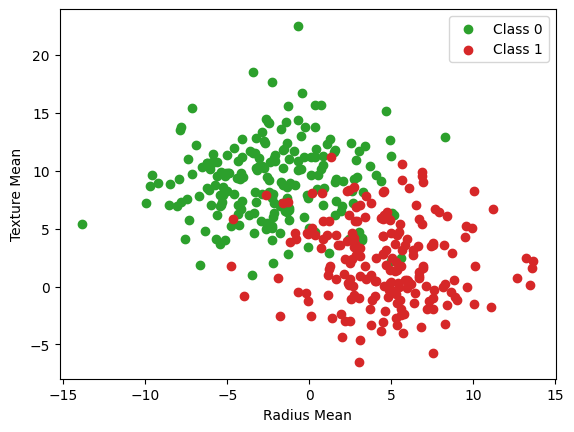

In [ ]:
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='tab:green', label='Class 0')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='tab:red', label='Class 1')
plt.xlabel('Radius Mean')
plt.ylabel('Texture Mean')
plt.legend()
plt.show()

In [ ]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((b - a) ** 2))

In [ ]:
class KNN:
    def __init__(self, k):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, new_points):
        predictions = [self.predict_class(new_point) for new_point in new_points]
        return np.array(predictions)
    
    def predict_class(self, new_point):
        distances = [euclidean_distance(point, new_point) for point in self.X_train]

        k_nearest_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_nearest_indices]

        most_common = Counter(k_nearest_labels).most_common(1)[0][0]

        return most_common

In [ ]:
knn = KNN(3)
knn.fit(X_train_scaled, y_train)
predictions = knn.predict(X_test_scaled)
accuracy = np.mean(predictions == y_test) * 100
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 96.00%


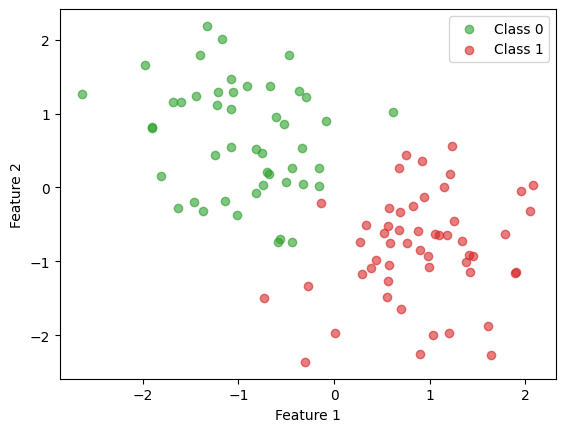

In [ ]:
plt.scatter(X_test_scaled[predictions == 0, 0], X_test_scaled[predictions == 0, 1], color='tab:green', label='Class 0', alpha=0.6)
plt.scatter(X_test_scaled[predictions == 1, 0], X_test_scaled[predictions == 1, 1], color='tab:red', label='Class 1', alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()